In [ ]:
from sqlalchemy import create_engine
from snowflake.sqlalchemy import URL
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

c:\Users\knguy139\Documents\Projects\.venv\Lib\site-packages\snowflake\connector\vendored\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(


In [ ]:
# Connect to Snowflake
engine = create_engine(URL(
    account = "UHG-UHGDWAAS",
    user = "KHANG.NGUYEN@UHC.COM",
    authenticator = "externalbrowser",
    role = "AZU_SDRP_VING_PRD_DEVELOPER_ROLE",
    warehouse = "VING_PRD_MNR_HCE_DATAINFRA_WH",
    database = "VING_PRD_TREND_DB",
    schema = "TMP_1M"
))

In [ ]:
# hospital_group aggregation — MNR FFS, 2025 only (202501-202512)
df = pd.read_sql("""
    select
        d.collection as hospital_group
        , a.fin_market
        , count(distinct a.case_id) as case_count_2025
        , count(distinct case when a.initialfulladr_cases = 1 then a.case_id end) as initial_adr_cnt_2025
        , count(distinct case when a.persistentfulladr_cases = 1 then a.case_id end) as persistent_adr_cnt
        , count(distinct case when a.p2p_full_ovtn = 1 then a.case_id end) as p2p_ovrtn_cnt
        , count(distinct case when a.appeal_ovrtn_ind = 1 then a.case_id end) as appeal_ovrtn_cnt
        , count(distinct case when a.mcr_ovtrn_ind = 1 then a.case_id end) as mcr_ovrtn_cnt
        , count(distinct case when a.icm_md_reviewed_ind = 1 then a.case_id end) as md_reviewed_cnt
    from tmp_1m.ec_avtar_25_26_3_od as a
    left join tmp_1y.tin_collection as d
        on substr(a.fa_prov_id, 2, 9) = d.tin
    where fin_brand = 'M&R'
        and (
            (ip_type in ('Medical', 'Surgical', 'Transplant')
             and to_varchar(admit_dt_act, 'MM/dd/yyyy') is not null)
            or ip_type in ('LTAC', 'SNF', 'AIR')
        )
        and loc_flag = 1
        and (
            (global_cap = 'NA' and sgr_source_name = 'COSMOS'
             and fin_product_level_3 != 'INSTITUTIONAL' and tfm_include_flag = 1)
            or (sgr_source_name = 'NICE' and nce_tadm_dec_risk_type in ('FFS', 'PHYSICIAN'))
        )
        and hce_admit_month between '202501' and '202512'
        and d.collection is not null
    group by 1,2
""", engine)

print(f"Core (2025): {df.shape}")

 pip install snowflake-connector-python[secure-local-storage]


Initiating login request with your identity provider. Press CTRL+C to abort and try again...
Going to open: https://login.microsoftonline.com/db05faca-c82a-4b9d-b9c5-0f64b6755421/saml2?SAMLRequest=lVLRbtowFP2VyHtO7ISQFQuoWFE3NrqyAlvXl8mJb8CqY2e2Q9p9%2FZwAUvfQSnuwZNnn3HPuPXd8%2BVTJ4ADGCq0mKI4ICkAVmgu1m6Dt5jq8QIF1THEmtYIJegaLLqdjyypZ01nj9uoOfjdgXeALKUu7jwlqjKKaWWGpYhVY6gq6nt0saRIRyqwF47wcOlG4FV5r71xNMW7bNmoHkTY7nBBCMBlhj%2Bog79ALifptjdpopwstz5Qn39MrEjEmaSfhEV5hdSJ%2BEOo4grdU8iPI0k%2BbzSpc3a43KJidu7vSyjYVmDWYgyhge7c8GrDeQbPfhf7wljH7a88iq3RbSvYIha7qxvmakb%2FhEjiWeif8pBbzCaofBefuT3XIYJbr%2FOc9ZB%2B%2F%2FLg%2FbAVp089Lor49tLexvoFym%2FOSFCj4fs416XJdWNvAQnVpOv9EkiwkWRhnmzilA0KHgygdZQ8omPs0hWKuZ54t9z6iShRGW106raRQ0LvkORmWrGBhcZGwMM1HPMxHxTAkZZbm2fvhME1i3GWWoOPe0N6Imf7fNMb4Jfe0gF99Jov5SktRPAfX2lTMvR5ZHMX9i%2BBh2UMpVEzIGecGrPXRSanbKwPM%2BT13pgGEp0fVfzd9%2Bhc%3D&RelayState=ver%3A3-hint%3A260092117886646-ETMsDgAAAZ7Q16M4ABRBRVMvQ0JDL1BLQ1M1UGFkZGluZwEAABAAEA1kZRkIiquadZOj49WI158AAACQP20Z2m2MAG4ja1hp

In [ ]:
# member_appeal — 202601+ only (separate time range)
df_ma = pd.read_sql("""
    select
        d.collection as hospital_group
        , a.fin_market
        , count(distinct a.case_id) as case_count_2026
        , count(distinct case when a.initialfulladr_cases = 1 then a.case_id end) as initial_adr_cnt_2026
        , count(distinct case when a.member_appeal_ind = 1 then a.case_id end) as member_appeal_cnt
        , count(distinct case when a.member_appeal_ovtn_ind = 1 then a.case_id end) as member_appeal_ovtn_cnt
    from tmp_1m.ec_avtar_25_26_3_od as a
    left join tmp_1y.tin_collection as d
        on substr(a.fa_prov_id, 2, 9) = d.tin
    where fin_brand = 'M&R'
        and (
            (ip_type in ('Medical', 'Surgical', 'Transplant')
             and to_varchar(admit_dt_act, 'MM/dd/yyyy') is not null)
            or ip_type in ('LTAC', 'SNF', 'AIR')
        )
        and loc_flag = 1
        and (
            (global_cap = 'NA' and sgr_source_name = 'COSMOS'
             and fin_product_level_3 != 'INSTITUTIONAL' and tfm_include_flag = 1)
            or (sgr_source_name = 'NICE' and nce_tadm_dec_risk_type in ('FFS', 'PHYSICIAN'))
        )
        and hce_admit_month >= '202601'
        and d.collection is not null
    group by 1,2
""", engine)

engine.dispose()
print(f"Member appeal (202601+): {df_ma.shape}")

Member appeal (202601+): (8070, 6)


In [ ]:
# merge and compute rates
df = (
    df
    .merge(df_ma, on = ["hospital_group", "fin_market"], how = "left")
    .assign(
        initial_adr_rate_2025 = lambda x: x.initial_adr_cnt_2025 / x.case_count_2025,
        persistent_adr_rate = lambda x: x.persistent_adr_cnt / x.case_count_2025,
        p2p_overturn_rate = lambda x: x.p2p_ovrtn_cnt / x.initial_adr_cnt_2025.replace(0, np.nan),
        appeal_overturn_rate = lambda x: x.appeal_ovrtn_cnt / x.initial_adr_cnt_2025.replace(0, np.nan),
        mcr_overturn_rate = lambda x: x.mcr_ovrtn_cnt / x.initial_adr_cnt_2025.replace(0, np.nan),
        md_review_rate = lambda x: x.md_reviewed_cnt / x.case_count_2025,
        member_appeal_rate = lambda x: x.member_appeal_cnt / x.initial_adr_cnt_2026.replace(0, np.nan),
        initial_adr_rate_2026 = lambda x: x.initial_adr_cnt_2026 / x.case_count_2026,
    )
    .dropna(subset = ["p2p_overturn_rate", "member_appeal_rate"])
)

rate_cols = [
    "initial_adr_rate_2025", "persistent_adr_rate", "p2p_overturn_rate",
    "appeal_overturn_rate", "mcr_overturn_rate", "md_review_rate",
    "member_appeal_rate", "initial_adr_rate_2026"
]
count_cols = [
    "case_count_2025", "initial_adr_cnt_2025", "persistent_adr_cnt", "p2p_ovrtn_cnt",
    "appeal_ovrtn_cnt", "mcr_ovrtn_cnt", "md_reviewed_cnt",
    "case_count_2026", "member_appeal_cnt", "initial_adr_cnt_2026"
]
# Change null to 0
df[rate_cols + count_cols] = df[rate_cols + count_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"Shape: {df.shape[0]}")

Shape: 2768


In [ ]:

print(df.loc[df['hospital_group'] == 'ADVOCATE HEALTH & HOSPITALS IL', 
       ['case_count_2025', 'md_reviewed_cnt']].sum())


case_count_2025    7393
md_reviewed_cnt     169
dtype: int64


In [ ]:
# =============================================================================
# DATA PREP: Eligibility filter + Empirical Bayes shrinkage + log-volume features
# =============================================================================
from scipy.stats import median_abs_deviation

# Split a new df out for IF analysis
df_iso = df.copy()
df_iso[count_cols] = df_iso[count_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

# --- Eligibility filter: minimum volume thresholds ---
# Ensures flagged entities have enough sample size to be meaningful
df_iso = (
    df_iso
    .query("case_count_2025 >= 30 and initial_adr_cnt_2025 >= 10 and initial_adr_cnt_2026 >= 10")
    .copy()
)

# --- Empirical Bayes shrinkage (credibility weighting) ---
# adjusted_rate = (observed_num + k * global_rate) / (observed_den + k)
# k=50 pulls small-sample rates toward the population mean to reduce noise
# Hospitals with few cases get pulled more toward the global average
# Hospitals with many cases stay close to their observed rate.
k = 50

# global rates (population-level averages across all eligible hospitals)
gr_initial_adr_25 = df_iso["initial_adr_cnt_2025"].sum() / df_iso["case_count_2025"].sum()
gr_persistent = df_iso["persistent_adr_cnt"].sum() / df_iso["case_count_2025"].sum()
gr_p2p = df_iso["p2p_ovrtn_cnt"].sum() / df_iso["initial_adr_cnt_2025"].sum()
gr_appeal = df_iso["appeal_ovrtn_cnt"].sum() / df_iso["initial_adr_cnt_2025"].sum()
gr_mcr = df_iso["mcr_ovrtn_cnt"].sum() / df_iso["initial_adr_cnt_2025"].sum()
gr_md = df_iso["md_reviewed_cnt"].sum() / df_iso["case_count_2025"].sum()
gr_member_appeal = df_iso["member_appeal_cnt"].sum() / df_iso["initial_adr_cnt_2026"].sum()
gr_initial_adr_26 = df_iso["initial_adr_cnt_2026"].sum() / df_iso["case_count_2026"].sum()

# shrinkage-adjusted rates (overwrite the raw rates with stabilized versions)
df_iso = df_iso.assign(
    initial_adr_rate_2025 = lambda x: (x.initial_adr_cnt_2025 + k * gr_initial_adr_25) / (x.case_count_2025 + k),
    persistent_adr_rate = lambda x: (x.persistent_adr_cnt + k * gr_persistent) / (x.case_count_2025 + k),
    p2p_overturn_rate = lambda x: (x.p2p_ovrtn_cnt + k * gr_p2p) / (x.initial_adr_cnt_2025 + k),
    appeal_overturn_rate = lambda x: (x.appeal_ovrtn_cnt + k * gr_appeal) / (x.initial_adr_cnt_2025 + k),
    mcr_overturn_rate = lambda x: (x.mcr_ovrtn_cnt + k * gr_mcr) / (x.initial_adr_cnt_2025 + k),
    md_review_rate = lambda x: (x.md_reviewed_cnt + k * gr_md) / (x.case_count_2025 + k),
    member_appeal_rate = lambda x: (x.member_appeal_cnt + k * gr_member_appeal) / (x.initial_adr_cnt_2026 + k),
    initial_adr_rate_2026 = lambda x: (x.initial_adr_cnt_2026 + k * gr_initial_adr_26) / (x.case_count_2026 + k),
)

# --- Log-volume features ---
# Gives IF explicit volume signal so it can distinguish
# probable outlier vs "outlier due to small sample"
df_iso = df_iso.assign(
    log_case_count_2025 = lambda x: np.log1p(x.case_count_2025),
    log_initial_adr_cnt_2025 = lambda x: np.log1p(x.initial_adr_cnt_2025),
    log_initial_adr_cnt_2026 = lambda x: np.log1p(x.initial_adr_cnt_2026),
)

# --- Features going into Isolation Forest ---
iso_kpi = [
    "log_case_count_2025", "log_initial_adr_cnt_2025", "log_initial_adr_cnt_2026",
    "initial_adr_rate_2025", "persistent_adr_rate", "p2p_overturn_rate",
    "appeal_overturn_rate", "mcr_overturn_rate", "md_review_rate",
    "member_appeal_rate", "initial_adr_rate_2026"
]

df_iso[iso_kpi] = df_iso[iso_kpi].replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"IF-ready: {df_iso.shape[0]} hospitals, {len(iso_kpi)} features")

IF-ready: 893 hospitals, 11 features


In [ ]:
# =============================================================================
# ISOLATION FOREST: anomaly detection
# - Distribution-free; contamination=5% sets expected outlier proportion
# - 300 trees for stable scoring
# - StandardScaler normalizes features so no single metric dominates
# =============================================================================
scaler_iso = StandardScaler()
X_iso = scaler_iso.fit_transform(df_iso[iso_kpi])

iso_model = IsolationForest(contamination = 0.05, n_estimators = 300, random_state = 42)
iso_model.fit(X_iso)

df_iso = df_iso.assign(
    anomaly_score = iso_model.decision_function(X_iso),
    anomaly_flag = iso_model.predict(X_iso) == -1,
)
df_iso["anomaly_rank"] = df_iso["anomaly_score"].rank(method = "dense", ascending = True).astype(int)

print(f"Flagged: {df_iso['anomaly_flag'].sum()} / {df_iso.shape[0]} hospitals")

Flagged: 45 / 893 hospitals


In [ ]:
# =============================================================================
# MAD Z-SCORES (interpretability layer)
# - MAD z = (x - median) / (MAD * 1.4826)
# - 1.4826 = consistency constant making MAD comparable to SD under normality
# - Used for driver identification, NOT for IF model input
# - More robust to skew than standard z-scores
# =============================================================================
mad_z_cols = [f"{c}_z" for c in iso_kpi]

for col in iso_kpi:
    med = df_iso[col].median()
    mad_scaled = median_abs_deviation(df_iso[col], scale = 1.0) * 1.4826
    df_iso[f"{col}_z"] = (df_iso[col] - med) / mad_scaled if mad_scaled > 0 else 0

print(f"MAD z-scores computed for {len(iso_kpi)} features")

MAD z-scores computed for 11 features


In [ ]:
# =============================================================================
# DRIVER IDENTIFICATION
# - For each row: which MAD z-score has the largest absolute value?
# - That metric is the primary "reason" this hospital was flagged.
# =============================================================================
df_iso = df_iso.assign(
    driver = lambda x: x[mad_z_cols].abs().idxmax(axis = 1).str.removesuffix("_z"),
    z_score = lambda x: x[mad_z_cols].apply(lambda r: r[r.abs().idxmax()], axis = 1),
    direction = lambda x: np.where(x.z_score > 0, "high", "low"),
    reason = lambda x: np.where(x.anomaly_flag, x.driver + " (" + x.direction + ")", ""),
)

# --- Driver value, population median, and % deviation ---
# For log-transformed drivers, we report the raw count instead of the log value
# so the output is human-readable (e.g. "case_count = 500" not "log = 6.2")
pop_medians = df_iso[iso_kpi].median()
raw_med_case_count_2025 = df_iso["case_count_2025"].median()
raw_med_initial_adr_2025 = df_iso["initial_adr_cnt_2025"].median()
raw_med_initial_adr_2026 = df_iso["initial_adr_cnt_2026"].median()

df_iso["driver_value"] = np.nan
df_iso["driver_pop_median"] = np.nan
df_iso["driver_dev"] = np.nan

# log drivers → use raw values
mask = df_iso["anomaly_flag"] & (df_iso["driver"] == "log_case_count_2025")
df_iso.loc[mask, "driver_value"] = df_iso.loc[mask, "case_count_2025"]
df_iso.loc[mask, "driver_pop_median"] = raw_med_case_count_2025
df_iso.loc[mask, "driver_dev"] = (df_iso.loc[mask, "case_count_2025"] - raw_med_case_count_2025) / raw_med_case_count_2025

mask = df_iso["anomaly_flag"] & (df_iso["driver"] == "log_initial_adr_cnt_2025")
df_iso.loc[mask, "driver_value"] = df_iso.loc[mask, "initial_adr_cnt_2025"]
df_iso.loc[mask, "driver_pop_median"] = raw_med_initial_adr_2025
df_iso.loc[mask, "driver_dev"] = (df_iso.loc[mask, "initial_adr_cnt_2025"] - raw_med_initial_adr_2025) / raw_med_initial_adr_2025

mask = df_iso["anomaly_flag"] & (df_iso["driver"] == "log_initial_adr_cnt_2026")
df_iso.loc[mask, "driver_value"] = df_iso.loc[mask, "initial_adr_cnt_2026"]
df_iso.loc[mask, "driver_pop_median"] = raw_med_initial_adr_2026
df_iso.loc[mask, "driver_dev"] = (df_iso.loc[mask, "initial_adr_cnt_2026"] - raw_med_initial_adr_2026) / raw_med_initial_adr_2026

# rate drivers → use the rate value directly
for rate_col in rate_cols:
    mask = df_iso["anomaly_flag"] & (df_iso["driver"] == rate_col)
    if mask.any():
        df_iso.loc[mask, "driver_value"] = df_iso.loc[mask, rate_col]
        df_iso.loc[mask, "driver_pop_median"] = pop_medians[rate_col]
        df_iso.loc[mask, "driver_dev"] = (df_iso.loc[mask, rate_col] - pop_medians[rate_col]) / pop_medians[rate_col]

print(f"Drivers assigned for {df_iso['anomaly_flag'].sum()} flagged hospitals")

Drivers assigned for 45 flagged hospitals


In [ ]:
df_iso[df_iso['driver'] == 'md_review_rate']

,hospital_group,fin_market,case_count_2025,initial_adr_cnt_2025,persistent_adr_cnt,p2p_ovrtn_cnt,appeal_ovrtn_cnt,mcr_ovrtn_cnt,md_reviewed_cnt,case_count_2026,...,md_review_rate_z,member_appeal_rate_z,initial_adr_rate_2026_z,driver,z_score,direction,reason,driver_value,driver_pop_median,driver_dev
146,FIRSTHEALTH OF THE CAROLINAS INC,NC,1633,285,150,131,0,0,865,786.0,...,-1.859575,-1.464973,-1.072923,md_review_rate,-1.859575,low,,NaN,NaN,NaN
148,Portercare Adventist Health System,CO,4345,1107,652,459,8,2,2236,2057.0,...,-2.056274,-1.021690,-0.593774,md_review_rate,-2.056274,low,,NaN,NaN,NaN
156,INSPIRA MEDICAL CENTERS,PA,426,115,57,49,0,3,345,154.0,...,1.119763,-0.461773,0.063961,md_review_rate,1.119763,high,,NaN,NaN,NaN
161,SHANDS JACKSONVILLE MED CTR,GA,148,44,28,14,0,1,82,66.0,...,-1.337543,-0.110158,1.293516,md_review_rate,-1.337543,low,,NaN,NaN,NaN
371,Summa Health System,OH,741,153,112,31,1,0,406,442.0,...,-1.616974,-0.323635,-0.943070,md_review_rate,-1.616974,low,,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12247,PMO Advocates-Stony Brook Hospital,NY,473,28,23,0,0,1,57,152.0,...,-6.007925,2.143904,-1.880123,md_review_rate,-6.007925,low,md_review_rate (low),0.171361,0.695613,-0.753654
12250,ST ANTHONYS MEMORIAL HOSPITAL,IL,125,53,26,24,0,1,109,62.0,...,1.302493,0.059371,0.824161,md_review_rate,1.302493,high,,NaN,NaN,NaN
12258,UC Health (CO),WY,177,20,13,6,0,0,72,37.0,...,-2.689927,0.723829,-0.228425,md_review_rate,-2.689927,low,,NaN,NaN,NaN
12614,NCHMD,FL,1168,391,232,139,4,8,437,655.0,...,-3.553115,-1.097123,1.491901,md_review_rate,-3.553115,low,,NaN,NaN,NaN


In [ ]:
# =============================================================================
# OUTPUT ASSEMBLY
# =============================================================================
output_cols = [
    "hospital_group", "fin_market",
    "case_count_2025", "initial_adr_cnt_2025", "case_count_2026", "initial_adr_cnt_2026",
    *iso_kpi, *mad_z_cols,
    "anomaly_score", "anomaly_rank", "anomaly_flag",
    "driver", "z_score", "direction", "reason",
    "driver_value", "driver_pop_median", "driver_dev"
]

df_iso_output = df_iso[output_cols].sort_values("anomaly_score").reset_index(drop = True)

print(f"Model input: {df_iso.shape[0]} entities | Flagged: {df_iso['anomaly_flag'].sum()}")
df_iso_output

Model input: 893 entities | Flagged: 45


,hospital_group,fin_market,case_count_2025,initial_adr_cnt_2025,case_count_2026,initial_adr_cnt_2026,log_case_count_2025,log_initial_adr_cnt_2025,log_initial_adr_cnt_2026,initial_adr_rate_2025,...,anomaly_score,anomaly_rank,anomaly_flag,driver,z_score,direction,reason,driver_value,driver_pop_median,driver_dev
0,WESTCHESTER GENERAL HOSPITAL,FL,114,79,51.0,42.0,4.744932,4.382027,3.761200,0.570364,...,-0.094724,1,True,member_appeal_rate,6.967181,high,member_appeal_rate (high),0.082776,0.020448,3.048062
1,ADVOCATE HEALTH & HOSPITALS IL,IL,7393,78,3403.0,34.0,8.908424,4.369448,3.555348,0.012433,...,-0.092064,2,True,md_review_rate,-7.661289,low,md_review_rate (low),0.027089,0.695613,-0.961058
2,Stanford Health Hospital,CA-N,753,62,326.0,35.0,6.625392,4.143135,3.583519,0.095317,...,-0.085649,3,True,appeal_overturn_rate,13.826097,high,appeal_overturn_rate (high),0.056839,0.005154,10.028078
3,Atrium Health System,NC,15852,4912,6070.0,1958.0,9.671114,8.499640,7.580189,0.309806,...,-0.084660,4,True,member_appeal_rate,71.732105,high,member_appeal_rate (high),0.662159,0.020448,31.381973
4,Nassau Health,NY,128,75,46.0,26.0,4.859812,4.330733,3.295837,0.503032,...,-0.065955,5,True,member_appeal_rate,17.740116,high,member_appeal_rate (high),0.179150,0.020448,7.761097
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
888,ST TAMMANY PARISH HOSPITAL,LA,361,104,178.0,48.0,5.891644,4.653960,3.891820,0.288418,...,0.152136,889,False,member_appeal_rate,1.838118,high,,NaN,NaN,NaN
889,SOUTHEAST MO HOSP ASSOCIATION,MO,422,129,242.0,80.0,6.047372,4.867534,4.394449,0.304109,...,0.152869,890,False,appeal_overturn_rate,-0.831865,low,,NaN,NaN,NaN
890,Community Health Systems,NM,184,44,76.0,25.0,5.220356,3.806662,3.258097,0.250169,...,0.152898,891,False,log_initial_adr_cnt_2025,-0.627046,low,,NaN,NaN,NaN
891,ST CLAIR HOSPITAL,PA,406,101,149.0,46.0,6.008813,4.624973,3.850148,0.253376,...,0.154251,892,False,appeal_overturn_rate,-0.730457,low,,NaN,NaN,NaN


In [ ]:
# =============================================================================
# SHAP: Explain WHY Isolation Forest flagged each hospital
# - Unlike MAD-Z (which just finds the most extreme metric independently),
#   SHAP interrogates the actual IF model to find which features contributed
#   most to each hospital's anomaly score.
# - Catches combination effects (e.g. "high p2p + high appeal together")
#   that MAD-Z would miss.
# =============================================================================
import shap

# Create a SHAP explainer for the Isolation Forest model
# We use the scaled data (X_iso) since that's what the model saw
explainer = shap.TreeExplainer(iso_model)
shap_values = explainer.shap_values(X_iso)

# shap_values is a matrix: (n_hospitals x n_features)
# Each value = how much that feature pushed this hospital's anomaly score
# More negative = more contribution to being flagged as anomaly
print(f"SHAP values shape: {shap_values.shape}")
print(f"Features: {iso_kpi}")

c:\Users\knguy139\Documents\Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values shape: (893, 11)
Features: ['log_case_count_2025', 'log_initial_adr_cnt_2025', 'log_initial_adr_cnt_2026', 'initial_adr_rate_2025', 'persistent_adr_rate', 'p2p_overturn_rate', 'appeal_overturn_rate', 'mcr_overturn_rate', 'md_review_rate', 'member_appeal_rate', 'initial_adr_rate_2026']


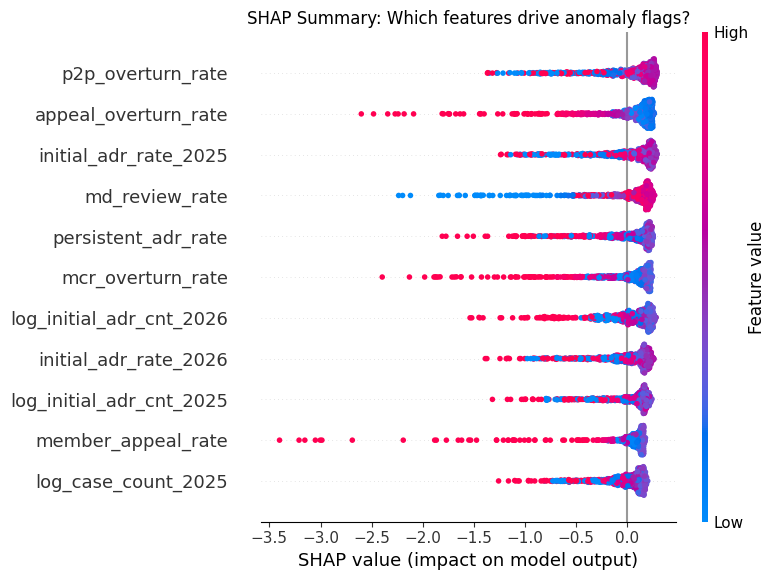

In [ ]:
# =============================================================================
# SHAP SUMMARY PLOT: Global feature importance
# - Shows which features matter MOST across all hospitals
# - Each dot = one hospital; x-axis = SHAP value (impact on anomaly score)
# - Color = feature value (red = high, blue = low)
# =============================================================================
shap.summary_plot(shap_values, X_iso, feature_names = iso_kpi, show = False)
plt.title("SHAP Summary: Which features drive anomaly flags?")
plt.tight_layout()
plt.show()

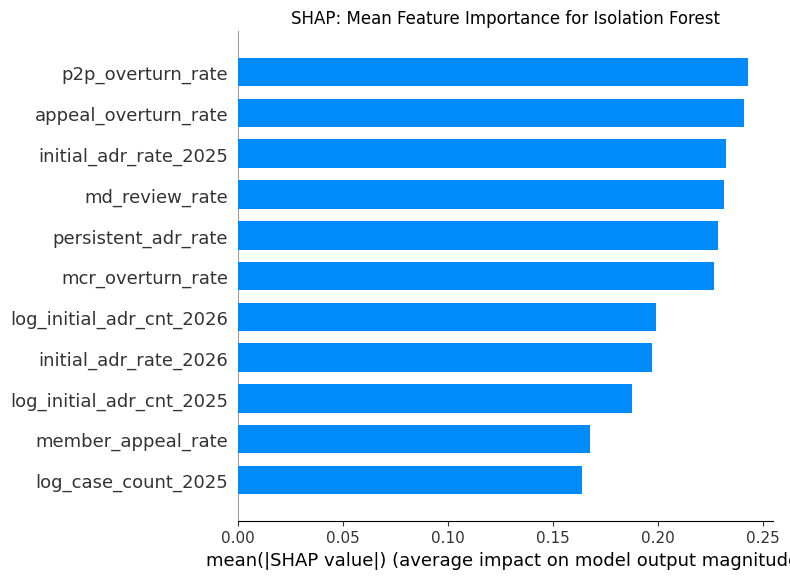

In [ ]:
# =============================================================================
# SHAP BAR PLOT: Mean absolute SHAP value per feature
# - Simpler view: just ranks features by overall importance
# - Higher bar = that feature matters more for IF's decisions
# =============================================================================
shap.summary_plot(shap_values, X_iso, feature_names = iso_kpi, plot_type = "bar", show = False)
plt.title("SHAP: Mean Feature Importance for Isolation Forest")
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# SHAP FOR FLAGGED HOSPITALS: Per-hospital breakdown
# - For each flagged hospital, shows which features pushed it toward anomaly
# - Compare with MAD-Z driver: do they agree?
# =============================================================================

flagged_idx = df_iso[df_iso["anomaly_flag"]].index
flagged_positions = [df_iso.index.get_loc(idx) for idx in flagged_idx]

shap_flagged = pd.DataFrame(
    shap_values[flagged_positions],
    columns = iso_kpi,
    index = flagged_idx
)

shap_flagged["hospital_group"] = df_iso.loc[flagged_idx, "hospital_group"].values
shap_flagged["fin_market"] = df_iso.loc[flagged_idx, "fin_market"].values
shap_flagged["anomaly_rank"] = df_iso.loc[flagged_idx, "anomaly_rank"].values
shap_flagged["mad_z_driver"] = df_iso.loc[flagged_idx, "driver"].values

shap_flagged["shap_driver"] = shap_flagged[iso_kpi].idxmin(axis = 1)
shap_flagged["shap_driver_value"] = shap_flagged[iso_kpi].min(axis = 1)

shap_flagged["drivers_agree"] = shap_flagged["mad_z_driver"] == shap_flagged["shap_driver"]

print(f"MAD-Z and SHAP drivers agree: {shap_flagged['drivers_agree'].sum()} / {len(shap_flagged)} ({shap_flagged['drivers_agree'].mean():.0%})")
print("="*60)
shap_flagged[["hospital_group", "fin_market", "anomaly_rank", "mad_z_driver", "shap_driver", "shap_driver_value", "drivers_agree"]].sort_values("anomaly_rank")

MAD-Z and SHAP drivers agree: 41 / 45 (91%)


,hospital_group,fin_market,anomaly_rank,mad_z_driver,shap_driver,shap_driver_value,drivers_agree
6148,WESTCHESTER GENERAL HOSPITAL,FL,1,member_appeal_rate,persistent_adr_rate,-1.389422,False
9839,ADVOCATE HEALTH & HOSPITALS IL,IL,2,md_review_rate,md_review_rate,-1.843168,True
10662,Stanford Health Hospital,CA-N,3,appeal_overturn_rate,appeal_overturn_rate,-2.240984,True
9615,Atrium Health System,NC,4,member_appeal_rate,member_appeal_rate,-3.050434,True
4541,Nassau Health,NY,5,member_appeal_rate,member_appeal_rate,-1.619659,True
8411,Froedtert,WI,6,mcr_overturn_rate,mcr_overturn_rate,-1.867544,True
6146,NORTH CAROLINA BAPTIST HOSPITAL SYSTEM,NC,7,member_appeal_rate,member_appeal_rate,-3.209811,True
566,HCA INC,FL,8,log_initial_adr_cnt_2026,log_initial_adr_cnt_2026,-1.537865,True
11040,Steward,FL,9,persistent_adr_rate,persistent_adr_rate,-1.773140,True
365,Novant Health System,NC,10,p2p_overturn_rate,log_initial_adr_cnt_2026,-1.229142,False



WESTCHESTER GENERAL HOSPITAL | Rank #1


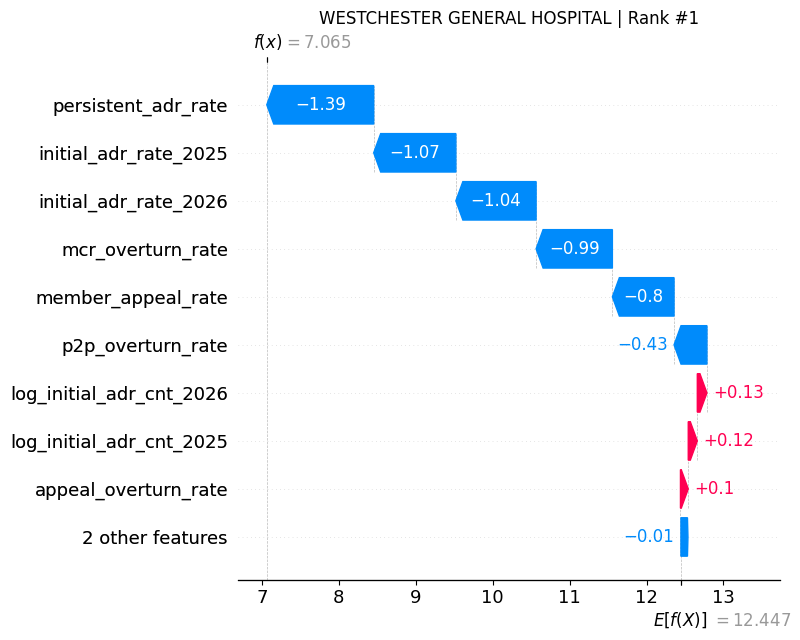


ADVOCATE HEALTH & HOSPITALS IL | Rank #2


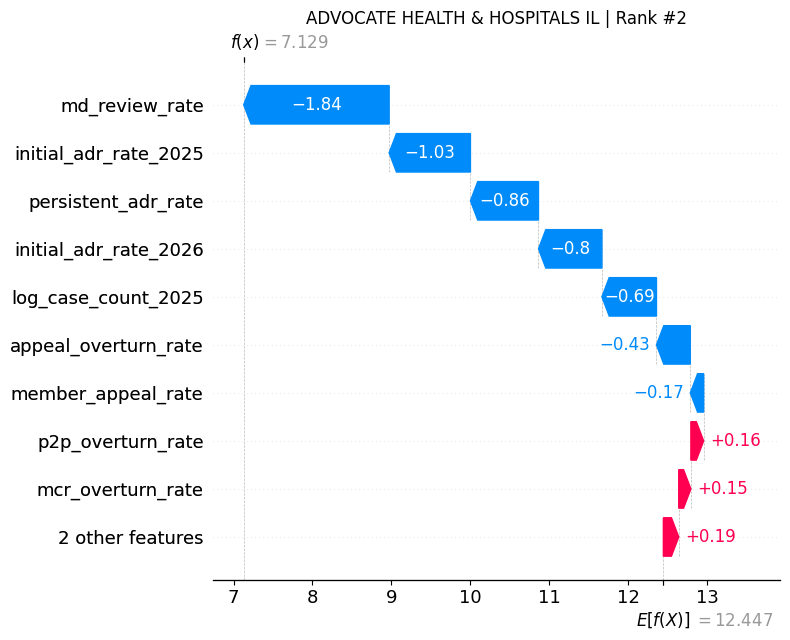


Stanford Health Hospital | Rank #3


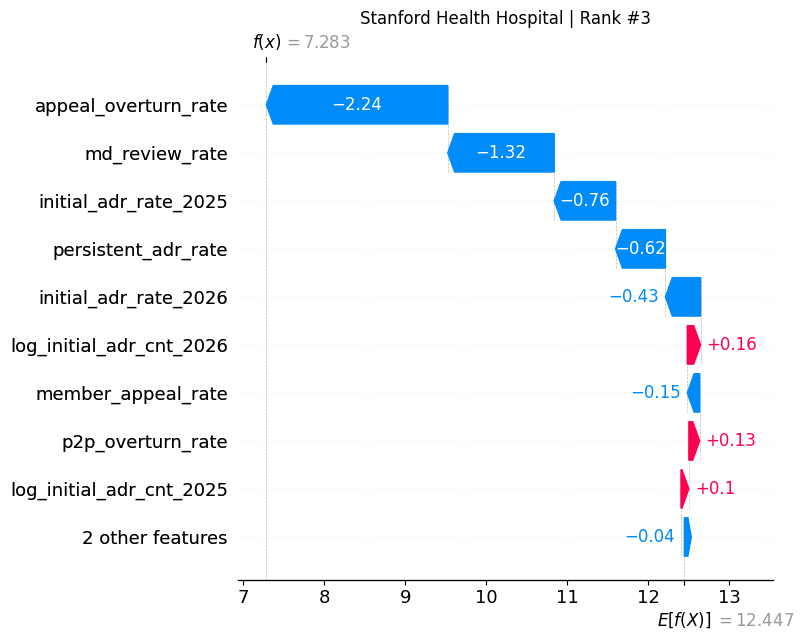


Atrium Health System | Rank #4


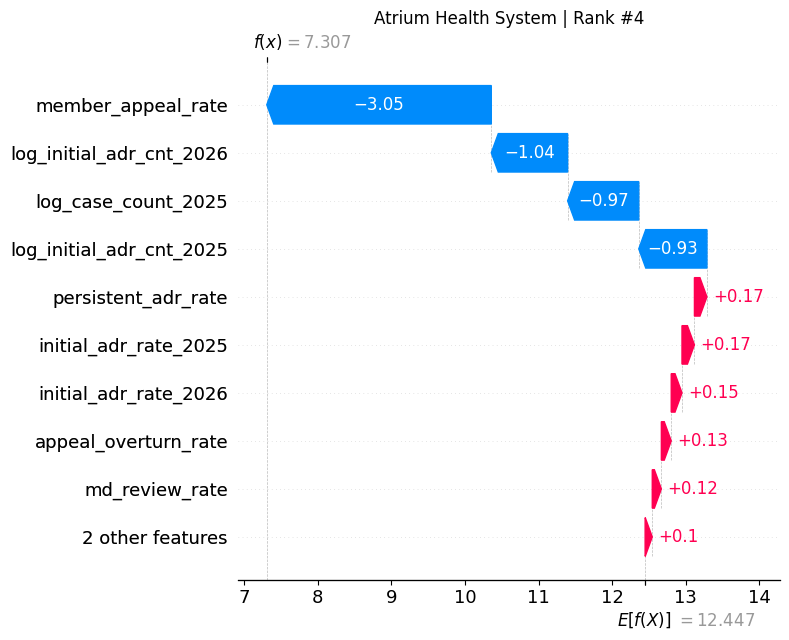


Nassau Health | Rank #5


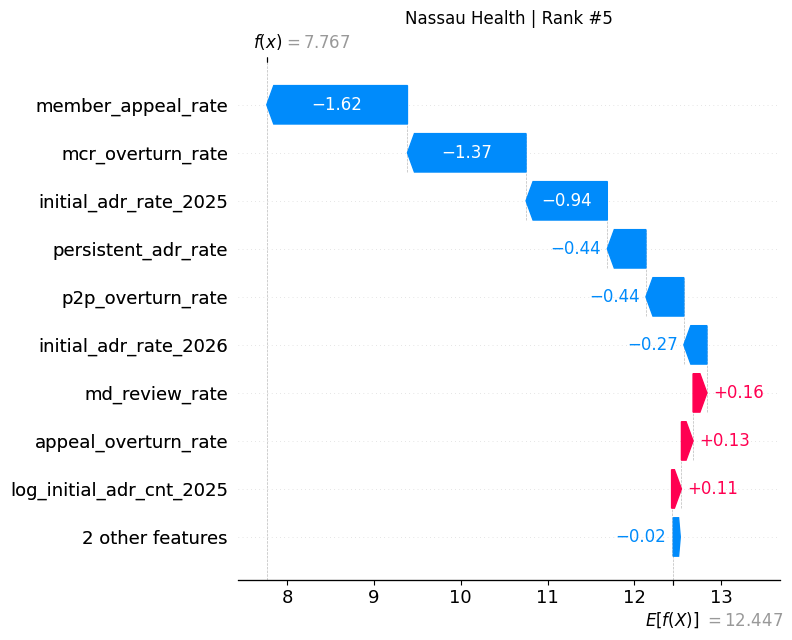

In [ ]:
# =============================================================================
# SHAP WATERFALL: Top 5 most anomalous hospitals
# - For each hospital, shows the cumulative effect of each feature
# - Bars going left = pushing toward anomaly
# - Bars going right = pushing toward normal
# =============================================================================

# Get the top 5 most anomalous (by rank)
top5_idx = (
    df_iso[df_iso["anomaly_flag"] & df_iso["hospital_group"].notna()]
    .nsmallest(5, "anomaly_score")
    .index
)

# expected_value can be an array for IF — extract scalar
base_val = float(explainer.expected_value) if np.ndim(explainer.expected_value) == 0 else float(explainer.expected_value[0])

for idx in top5_idx:
    pos = df_iso.index.get_loc(idx)
    hospital_name = df_iso.loc[idx, "hospital_group"]
    rank = int(df_iso.loc[idx, "anomaly_rank"])

    print(f"\n{'='*60}")
    print(f"{hospital_name} | Rank #{rank}")
    print(f"{'='*60}")

    explanation = shap.Explanation(
        values = shap_values[pos],
        base_values = base_val,
        feature_names = iso_kpi
    )
    shap.waterfall_plot(explanation, show = False)
    plt.title(f"{hospital_name[:35]} | Rank #{rank}")
    plt.tight_layout()
    plt.show()

Force plot for: WESTCHESTER GENERAL HOSPITAL (Rank #1)


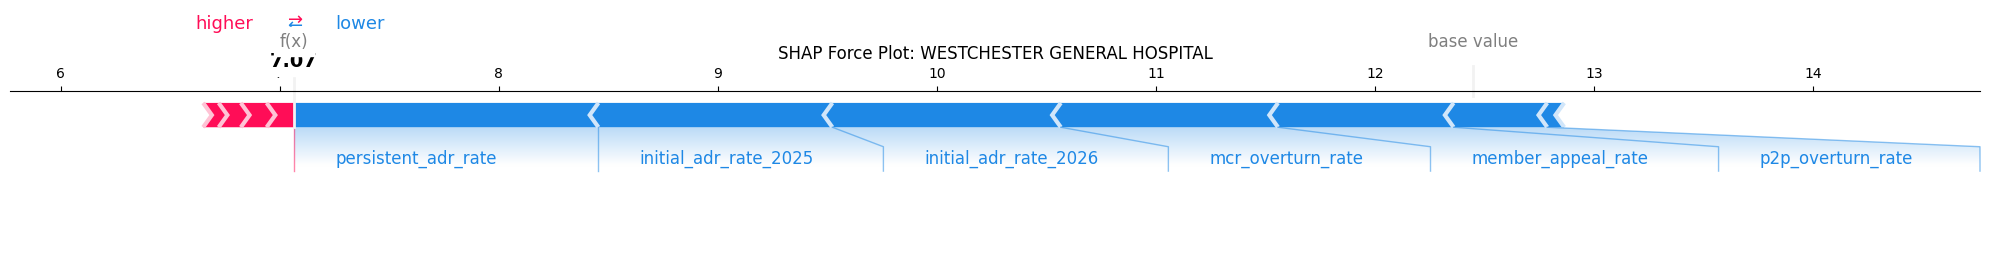

In [ ]:
# =============================================================================
# SHAP FORCE PLOT: Interactive view for a single hospital
# - Red features push toward anomaly, blue push toward normal
# - Width of each bar = magnitude of effect
# =============================================================================

# Show force plot for the #1 most anomalous hospital
top1_pos = df_iso.index.get_loc(top5_idx[0])
top1_name = df_iso.loc[top5_idx[0], "hospital_group"]

print(f"Force plot for: {top1_name} (Rank #1)")
shap.force_plot(
    base_val,
    shap_values[top1_pos],
    feature_names = iso_kpi,
    matplotlib = True,
    show = False
)
plt.title(f"SHAP Force Plot: {top1_name[:35]}")
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# DISAGREEMENTS: Hospitals where MAD-Z and SHAP picked different drivers
# - Shows both drivers + the SHAP values for all features so you can see
#   what SHAP thinks is actually driving the flag vs what MAD-Z picked
# =============================================================================
disagree = shap_flagged[~shap_flagged["drivers_agree"]].sort_values("anomaly_rank")

print(f"{len(disagree)} hospitals where MAD-Z and SHAP disagree on driver:")
print("="*80)

disagree[["hospital_group", "anomaly_rank", "mad_z_driver", "shap_driver", "shap_driver_value"]]

4 hospitals where MAD-Z and SHAP disagree on driver:


,hospital_group,anomaly_rank,mad_z_driver,shap_driver,shap_driver_value
6148,WESTCHESTER GENERAL HOSPITAL,1,member_appeal_rate,persistent_adr_rate,-1.389422
365,Novant Health System,10,p2p_overturn_rate,log_initial_adr_cnt_2026,-1.229142
10848,Albany Medical Center,14,appeal_overturn_rate,md_review_rate,-1.485652
3031,PIH Hospital,22,member_appeal_rate,persistent_adr_rate,-1.104419


In [ ]:
# Full SHAP breakdown for disagreement hospitals
# Shows all feature contributions so you can see WHY they disagree
disagree[[
    "hospital_group", "anomaly_rank", "mad_z_driver", "shap_driver",
    *iso_kpi
]].style.background_gradient(subset = iso_kpi, cmap = "RdBu", axis = 1)

,hospital_group,anomaly_rank,mad_z_driver,shap_driver,log_case_count_2025,log_initial_adr_cnt_2025,log_initial_adr_cnt_2026,initial_adr_rate_2025,persistent_adr_rate,p2p_overturn_rate,appeal_overturn_rate,mcr_overturn_rate,md_review_rate,member_appeal_rate,initial_adr_rate_2026
6148,WESTCHESTER GENERAL HOSPITAL,1,member_appeal_rate,persistent_adr_rate,-0.077040,0.117692,0.125027,-1.067792,-1.389422,-0.427452,0.101254,-0.991263,0.070745,-0.801301,-1.042767
365,Novant Health System,10,p2p_overturn_rate,log_initial_adr_cnt_2026,-1.101477,-0.997644,-1.229142,0.155994,-0.331814,-1.215272,0.167288,0.101221,0.076592,-0.035291,0.134947
10848,Albany Medical Center,14,appeal_overturn_rate,md_review_rate,0.035230,0.123618,-0.076825,-0.572260,-0.150948,-0.676353,-1.444526,0.104666,-1.485652,0.081689,-0.027814
3031,PIH Hospital,22,member_appeal_rate,persistent_adr_rate,0.099587,0.138476,0.196878,-0.613453,-1.104419,-0.954931,-0.124141,-0.904983,0.103099,-0.473528,-0.081458


In [ ]:
# =============================================================================
# WRITE FLAGGED HOSPITALS TO SNOWFLAKE
# =============================================================================
from sqlalchemy import create_engine
from snowflake.sqlalchemy import URL

engine_write = create_engine(URL(
    account = "UHG-UHGDWAAS",
    user = "KHANG.NGUYEN@UHC.COM",
    authenticator = "externalbrowser",
    role = "AZU_SDRP_VING_PRD_DEVELOPER_ROLE",
    warehouse = "VING_PRD_MNR_HCE_DATAINFRA_WH",
    database = "VING_PRD_TREND_DB",
    schema = "TMP_1M"
))

flagged = df_iso_output[df_iso_output["anomaly_flag"] == True].copy()
flagged["mad_z_driver"] = flagged["driver"]

shap_lookup = shap_flagged[["hospital_group", "fin_market", "shap_driver"]].reset_index(drop = True)
flagged = flagged.merge(
    shap_lookup,
    on = ["hospital_group", "fin_market"],
    how = "left"
)

flagged.columns = [c.upper() for c in flagged.columns]

flagged.to_sql(
    "kn_loc_if_outlier_hospitals_mnr",
    engine_write,
    schema = "TMP_1M",
    if_exists = "replace",
    index = False
)

engine_write.dispose()
print(f"Wrote {len(flagged)} flagged hospitals to TMP_1M.KN_LOC_IF_OUTLIER_HOSPITALS_MNR")
print(f"Columns: HOSPITAL_GROUP, FIN_MARKET, MAD_Z_DRIVER, SHAP_DRIVER")

 pip install snowflake-connector-python[secure-local-storage]


Initiating login request with your identity provider. Press CTRL+C to abort and try again...
Going to open: https://login.microsoftonline.com/db05faca-c82a-4b9d-b9c5-0f64b6755421/saml2?SAMLRequest=lVJdb%2BIwEPwrke85nyS5YgEVBVWlX4dKqK68nBzbCRaJnXqdpv335wSQeg%2BtdA%2BWLHtmZ3ZnJ5fvdeW8cQ1CySkKvQA5XFLFhCynaJtduxfIAUMkI5WSfIo%2BOKDL2QRIXTV43pq9fOKvLQfj2EIScP8xRa2WWBEQgCWpOWBD8Wb%2BcI8jL8AEgGtj5dCJwkBYrb0xDfb9ruu8buQpXfpREAR%2BMPYtqof8QJ8kmu81Gq2Moqo6U95tT19IhH4Q9xIWYRXWJ%2BKVkMcRfKeSH0GAb7Js7a5%2FbTLkzM%2FdLZSEtuZ6w%2FWboHz7dH80ANZBuy9de1hHCPzZEw%2Bk6oqKHDhVddMaW9OzN7%2FgzK9UKeykVsspag6CxXfhS77Ibg8XOXu5fbyD55DkN1H8u0vL13pT8mQ932c7ebXbUuQ8n3ON%2BlxXAC1fyT5NY5%2BCKHWD1A3TLIzxKMRh4o2SZIecpU1TSGIG5tny4MOrBdUKVGGUrITkg0uWB0lBKHHpRUTcOB8zNx%2FTxA2KNM7Tn0kSR6HfZxah497gwYie%2Fd80Jv5n7mkBH20mq%2BVaVYJ%2BONdK18R8HVnohcOLYG4xQDGviajmjGkOYKOrKtUtNCfG7rnRLUf%2B7Kj676bP%2FgI%3D&RelayState=ver%3A3-hint%3A260092117886646-ETMsDgAAAZ7Q1%2FibABRBRVMvQ0JDL1BLQ1M1UGFkZGluZwEAABAAEMaN9%2FreR1LwtLny3EouBeMAAACQ4%

In [ ]:
pop_medians_iso = df_iso[iso_kpi].median()

comparison = shap_flagged[["hospital_group", "fin_market", "anomaly_rank", "mad_z_driver", "shap_driver", "drivers_agree"]].copy()

comparison["mad_z_driver_val"] = comparison.apply(
    lambda r: df_iso.loc[df_iso["hospital_group"] == r["hospital_group"], r["mad_z_driver"]].values[0]
    if r["mad_z_driver"] in iso_kpi else np.nan, axis = 1
)
comparison["mad_z_pop_median"] = comparison["mad_z_driver"].map(pop_medians_iso)

comparison["shap_driver_val"] = comparison.apply(
    lambda r: df_iso.loc[df_iso["hospital_group"] == r["hospital_group"], r["shap_driver"]].values[0]
    if r["shap_driver"] in iso_kpi else np.nan, axis = 1
)
comparison["shap_pop_median"] = comparison["shap_driver"].map(pop_medians_iso)

comparison.sort_values("anomaly_rank")

,hospital_group,fin_market,anomaly_rank,mad_z_driver,shap_driver,drivers_agree,mad_z_driver_val,mad_z_pop_median,shap_driver_val,shap_pop_median
6148,WESTCHESTER GENERAL HOSPITAL,FL,1,member_appeal_rate,persistent_adr_rate,False,0.082776,0.020448,0.376114,0.151218
9839,ADVOCATE HEALTH & HOSPITALS IL,IL,2,md_review_rate,md_review_rate,True,0.027089,0.695613,0.027089,0.695613
10662,Stanford Health Hospital,CA-N,3,appeal_overturn_rate,appeal_overturn_rate,True,0.056839,0.005154,0.056839,0.005154
9615,Atrium Health System,NC,4,member_appeal_rate,member_appeal_rate,True,0.407621,0.020448,0.407621,0.020448
4541,Nassau Health,NY,5,member_appeal_rate,member_appeal_rate,True,0.179150,0.020448,0.179150,0.020448
8411,Froedtert,WI,6,mcr_overturn_rate,mcr_overturn_rate,True,0.153582,0.023144,0.153582,0.023144
6146,NORTH CAROLINA BAPTIST HOSPITAL SYSTEM,NC,7,member_appeal_rate,member_appeal_rate,True,0.122829,0.020448,0.122829,0.020448
566,HCA INC,FL,8,log_initial_adr_cnt_2026,log_initial_adr_cnt_2026,True,6.630683,3.970292,6.630683,3.970292
11040,Steward,FL,9,persistent_adr_rate,persistent_adr_rate,True,0.385894,0.151218,0.385894,0.151218
365,Novant Health System,NC,10,p2p_overturn_rate,log_initial_adr_cnt_2026,False,0.069530,0.374874,7.551187,3.970292
